In [1]:
#Cargar librerias
import pandas as pd
import os
import tarfile
import urllib.request
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import seaborn as sns
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.preprocessing import LabelEncoder

### importar el dataset

In [2]:
data=pd.read_csv('currentPriceCrypto.csv')

In [3]:
data.head()

,timestamp,cryptocurrency,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
0,2025-06-04 20:36:49,Algorand,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,95.1,37.2,78.1
1,2025-06-04 20:48:25,Cosmos,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,76.7,65.0,66.7
2,2025-06-04 21:28:54,Cosmos,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,60.4,32.3,77.4
3,2025-06-04 21:57:48,Ethereum,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,100.0,63.0,81.7
4,2025-06-04 22:06:40,Solana,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,67.5,55.4,81.8


In [4]:
data.tail()

,timestamp,cryptocurrency,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
2058,2025-07-04 17:16:03,Cardano,0.4492,-4.66,6345791.01,8.185563e+09,0.327,0.009,2.54,1695,56.5,77.3,51.9,72.4
2059,2025-07-04 17:25:39,Ethereum,3077.3009,0.33,590629.81,2.546980e+13,-0.277,-0.143,2.31,1093,40.1,30.4,40.5,79.2
2060,2025-07-04 17:43:50,Polkadot,8.1297,11.93,24276229.78,1.224982e+11,0.216,0.001,3.07,401,51.7,93.3,41.6,71.0
2061,2025-07-04 19:31:59,Polygon,1.1212,-7.76,2126227.67,2.240884e+10,0.144,0.160,2.32,202,66.3,76.2,37.6,74.8
2062,2025-07-04 19:58:28,Ethereum,3312.5590,3.12,9458225.78,2.011575e+13,0.005,0.622,5.02,276,53.5,71.3,42.7,72.8


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2063 entries, 0 to 2062
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 2063 non-null   object 
 1   cryptocurrency            2063 non-null   object 
 2   current_price_usd         2063 non-null   float64
 3   price_change_24h_percent  2063 non-null   float64
 4   trading_volume_24h        2063 non-null   float64
 5   market_cap_usd            2063 non-null   float64
 6   social_sentiment_score    2063 non-null   float64
 7   news_sentiment_score      2063 non-null   float64
 8   news_impact_score         2063 non-null   float64
 9   social_mentions_count     2063 non-null   int64  
 10  fear_greed_index          2063 non-null   float64
 11  volatility_index          2063 non-null   float64
 12  rsi_technical_indicator   2063 non-null   float64
 13  prediction_confidence     2063 non-null   float64
dtypes: float

In [6]:
data.describe()

,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
count,2063.000000,2063.000000,2.063000e+03,2.063000e+03,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000
mean,4260.360520,-0.018042,5.889564e+06,4.568510e+13,0.011158,0.002375,3.688366,1218.317014,50.494910,76.436937,50.501503,77.123413
std,12603.767442,8.000837,7.451165e+06,1.581473e+14,0.303325,0.308788,1.712072,2501.245623,13.367164,21.245765,15.116517,6.651359
min,0.298700,-25.560000,2.060664e+05,5.022090e+07,-1.000000,-1.000000,0.070000,2.000000,0.000000,21.400000,1.400000,55.900000
25%,1.208650,-5.755000,1.835157e+06,1.113379e+10,-0.197500,-0.202000,2.390000,143.500000,41.400000,60.700000,40.250000,72.650000
50%,13.344200,0.020000,3.633502e+06,1.255924e+11,0.012000,0.007000,3.670000,409.000000,50.600000,79.000000,50.500000,76.700000
75%,84.970000,5.755000,7.111602e+06,7.634962e+11,0.215000,0.211500,4.970000,1178.000000,59.400000,100.000000,60.550000,81.100000
max,51610.923200,27.080000,1.402925e+08,1.009556e+15,1.000000,1.000000,9.530000,35578.000000,100.000000,100.000000,97.100000,100.000000


In [7]:
## codificar la variable cryptocurrency para que sea un int y poder proceasrla

data = pd.get_dummies(
    data,
    columns=['cryptocurrency'],
    drop_first=True
)

dummy_cols = [c for c in data.columns if c.startswith('cryptocurrency_')]
data[dummy_cols] = data[dummy_cols].astype(int)

In [8]:
data.head()

,timestamp,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,...,prediction_confidence,cryptocurrency_Avalanche,cryptocurrency_Bitcoin,cryptocurrency_Cardano,cryptocurrency_Chainlink,cryptocurrency_Cosmos,cryptocurrency_Ethereum,cryptocurrency_Polkadot,cryptocurrency_Polygon,cryptocurrency_Solana
0,2025-06-04 20:36:49,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,...,78.1,0,0,0,0,0,0,0,0,0
1,2025-06-04 20:48:25,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,...,66.7,0,0,0,0,1,0,0,0,0
2,2025-06-04 21:28:54,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,...,77.4,0,0,0,0,1,0,0,0,0
3,2025-06-04 21:57:48,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,...,81.7,0,0,0,0,0,1,0,0,0
4,2025-06-04 22:06:40,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,...,81.8,0,0,0,0,0,0,0,0,1


In [9]:
### eliminar formato original de la fecha
data.drop('timestamp', axis=1, inplace=True)

In [10]:
data.head()

,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,...,prediction_confidence,cryptocurrency_Avalanche,cryptocurrency_Bitcoin,cryptocurrency_Cardano,cryptocurrency_Chainlink,cryptocurrency_Cosmos,cryptocurrency_Ethereum,cryptocurrency_Polkadot,cryptocurrency_Polygon,cryptocurrency_Solana
0,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,95.1,...,78.1,0,0,0,0,0,0,0,0,0
1,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,76.7,...,66.7,0,0,0,0,1,0,0,0,0
2,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,60.4,...,77.4,0,0,0,0,1,0,0,0,0
3,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,100.0,...,81.7,0,0,0,0,0,1,0,0,0
4,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,67.5,...,81.8,0,0,0,0,0,0,0,0,1


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2063 entries, 0 to 2062
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   current_price_usd         2063 non-null   float64
 1   price_change_24h_percent  2063 non-null   float64
 2   trading_volume_24h        2063 non-null   float64
 3   market_cap_usd            2063 non-null   float64
 4   social_sentiment_score    2063 non-null   float64
 5   news_sentiment_score      2063 non-null   float64
 6   news_impact_score         2063 non-null   float64
 7   social_mentions_count     2063 non-null   int64  
 8   fear_greed_index          2063 non-null   float64
 9   volatility_index          2063 non-null   float64
 10  rsi_technical_indicator   2063 non-null   float64
 11  prediction_confidence     2063 non-null   float64
 12  cryptocurrency_Avalanche  2063 non-null   int64  
 13  cryptocurrency_Bitcoin    2063 non-null   int64  
 14  cryptocu

In [12]:
##comprobar que no hay datos nulos

data.isnull().sum()

current_price_usd           0
price_change_24h_percent    0
trading_volume_24h          0
market_cap_usd              0
social_sentiment_score      0
news_sentiment_score        0
news_impact_score           0
social_mentions_count       0
fear_greed_index            0
volatility_index            0
rsi_technical_indicator     0
prediction_confidence       0
cryptocurrency_Avalanche    0
cryptocurrency_Bitcoin      0
cryptocurrency_Cardano      0
cryptocurrency_Chainlink    0
cryptocurrency_Cosmos       0
cryptocurrency_Ethereum     0
cryptocurrency_Polkadot     0
cryptocurrency_Polygon      0
cryptocurrency_Solana       0
dtype: int64

In [13]:
data.describe()

,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,...,prediction_confidence,cryptocurrency_Avalanche,cryptocurrency_Bitcoin,cryptocurrency_Cardano,cryptocurrency_Chainlink,cryptocurrency_Cosmos,cryptocurrency_Ethereum,cryptocurrency_Polkadot,cryptocurrency_Polygon,cryptocurrency_Solana
count,2063.000000,2063.000000,2.063000e+03,2.063000e+03,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,...,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000
mean,4260.360520,-0.018042,5.889564e+06,4.568510e+13,0.011158,0.002375,3.688366,1218.317014,50.494910,76.436937,...,77.123413,0.107126,0.086282,0.095977,0.101794,0.099855,0.110519,0.098885,0.105187,0.096461
std,12603.767442,8.000837,7.451165e+06,1.581473e+14,0.303325,0.308788,1.712072,2501.245623,13.367164,21.245765,...,6.651359,0.309348,0.280848,0.294631,0.302450,0.299879,0.313611,0.298580,0.306868,0.295295
min,0.298700,-25.560000,2.060664e+05,5.022090e+07,-1.000000,-1.000000,0.070000,2.000000,0.000000,21.400000,...,55.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.208650,-5.755000,1.835157e+06,1.113379e+10,-0.197500,-0.202000,2.390000,143.500000,41.400000,60.700000,...,72.650000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,13.344200,0.020000,3.633502e+06,1.255924e+11,0.012000,0.007000,3.670000,409.000000,50.600000,79.000000,...,76.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,84.970000,5.755000,7.111602e+06,7.634962e+11,0.215000,0.211500,4.970000,1178.000000,59.400000,100.000000,...,81.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,51610.923200,27.080000,1.402925e+08,1.009556e+15,1.000000,1.000000,9.530000,35578.000000,100.000000,100.000000,...,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


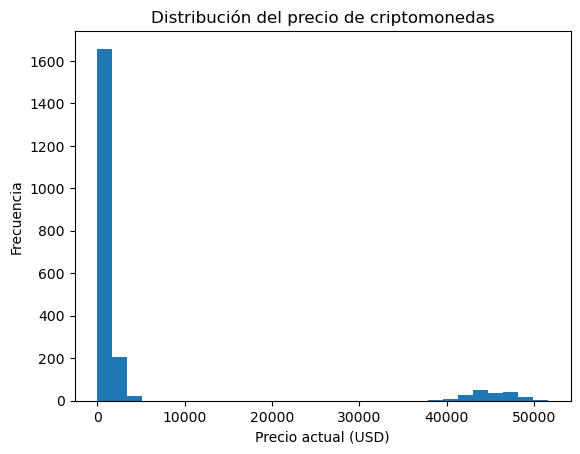

In [14]:
plt.hist(data['current_price_usd'], bins=30)
plt.xlabel('Precio actual (USD)')
plt.ylabel('Frecuencia')
plt.title('Distribución del precio de criptomonedas')
plt.show()

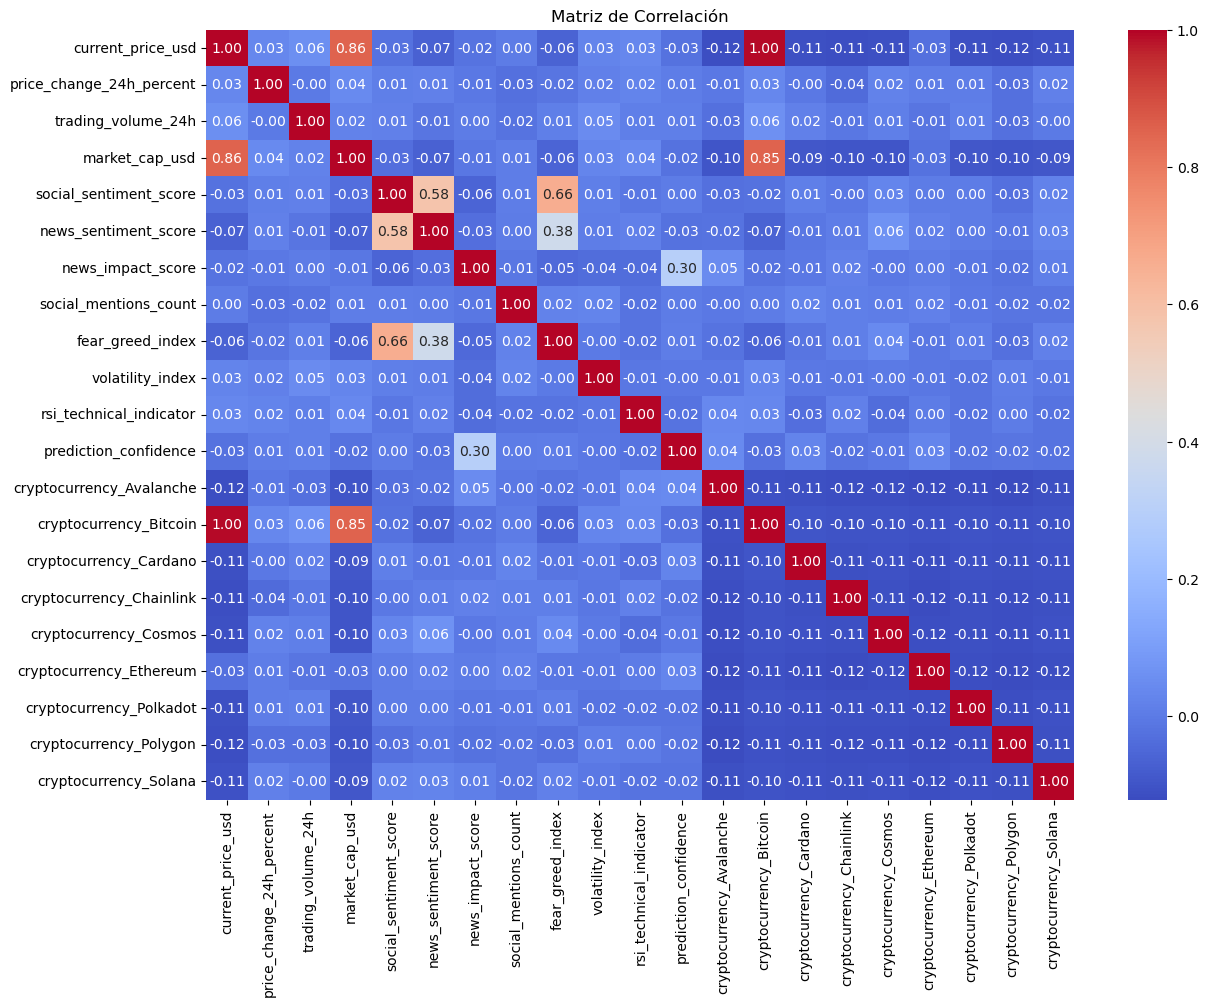

In [15]:
# Matriz de correlación
corr = data.corr(numeric_only=True)

# Gráfico
plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    annot=True,      # muestra los valores
    cmap='coolwarm', # colores
    fmt='.2f'
)

plt.title('Matriz de Correlación')
plt.show()

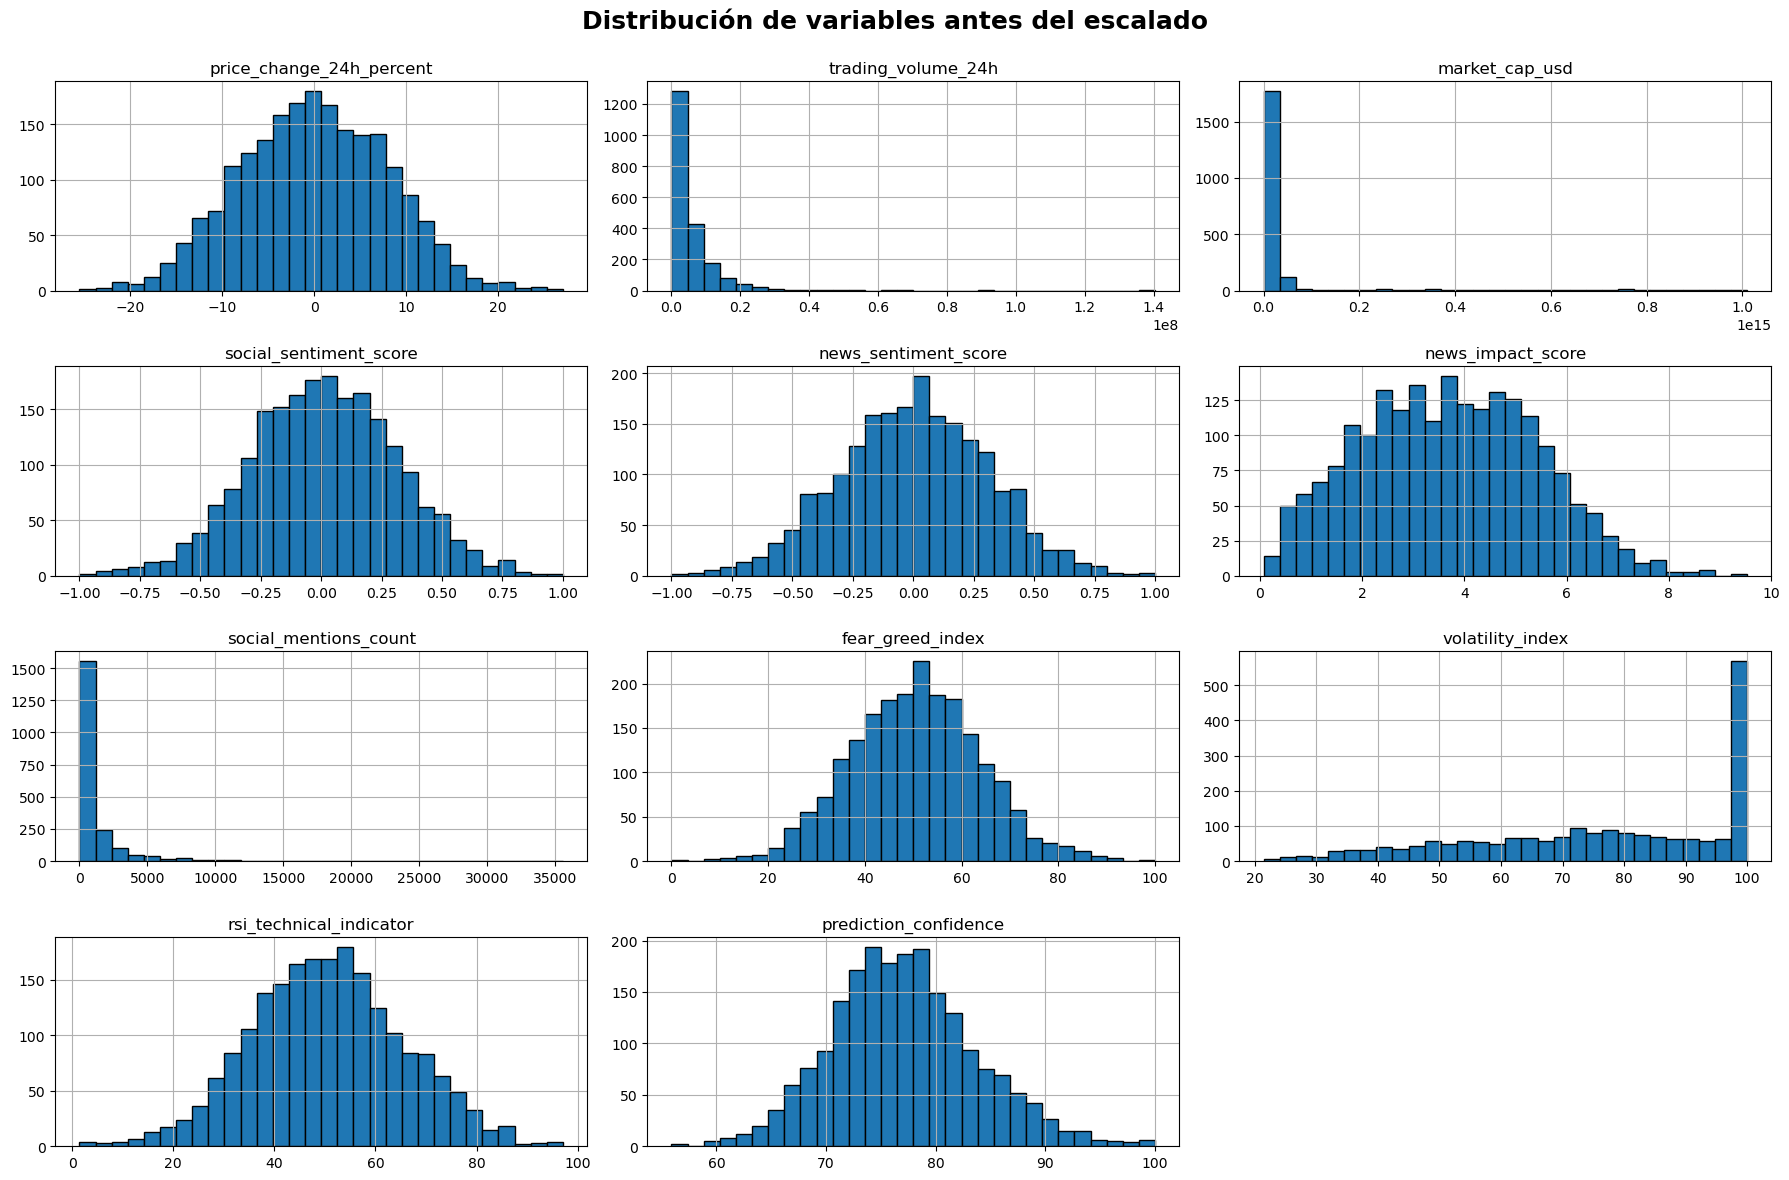

In [24]:
##grafica de datos antes de estandarizar
import matplotlib.pyplot as plt

columnas = [
    "price_change_24h_percent",
    "trading_volume_24h",
    "market_cap_usd",
    "social_sentiment_score",
    "news_sentiment_score",
    "news_impact_score",
    "social_mentions_count",
    "fear_greed_index",
    "volatility_index",
    "rsi_technical_indicator",
    "prediction_confidence"
]

# Crear histogramas
data[columnas].hist(
    figsize=(18, 12),   # tamaño general
    bins=30,            # cantidad de barras
    edgecolor="black",  # borde de barras
    layout=(4,3)        # filas y columnas
)

# Título general
plt.suptitle(
    "Distribución de variables antes del escalado",
    fontsize=18,
    fontweight="bold"
)

# Ajustar espacios
plt.tight_layout()

# Separar un poco el título
plt.subplots_adjust(top=0.92)

plt.show()

In [16]:
## seleccion de variables

y = data['current_price_usd']
X = data.drop('current_price_usd', axis=1)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [19]:
## estandarizacion

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
##entrenamiento del modelo
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = model.predict(X_test)

In [28]:
##evaluacion del r2
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print('el r2 es de: ',r2)

el r2 es de:  0.99641166362265


In [29]:
###evaluacion del mae
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print('el mae es de: ',mae)

el mae es de:  212.88639316833948


In [30]:
##evaluacion del rmse
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)
print('el rmse es de', rmse)

el rmse es de 740.9931531093505


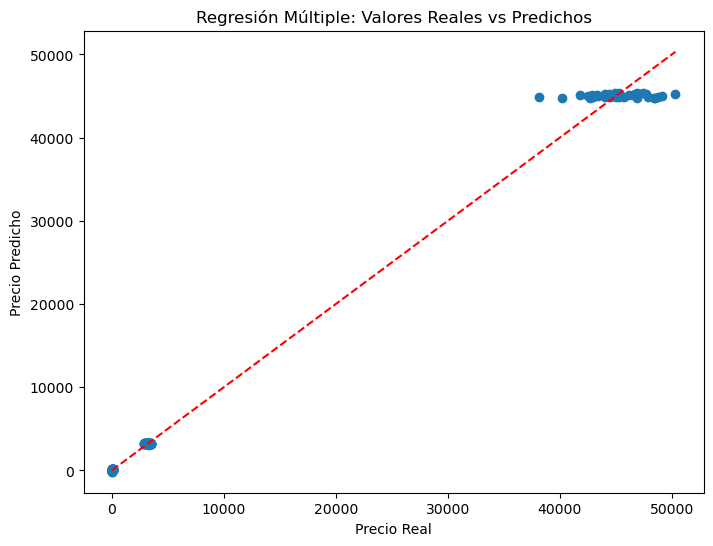

In [27]:
###graficar resultado 
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Regresión Múltiple: Valores Reales vs Predichos')

plt.show()

In [33]:
### calcular multicolinialidad from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif)

                    Variable       VIF
0                      const  0.000000
1   price_change_24h_percent  1.007652
2         trading_volume_24h  1.005396
3             market_cap_usd  3.716988
4     social_sentiment_score  2.186126
5       news_sentiment_score  1.519917
6          news_impact_score  1.100985
7      social_mentions_count  1.003624
8           fear_greed_index  1.540593
9           volatility_index  0.936119
10   rsi_technical_indicator  0.942568
11     prediction_confidence  0.414028
12  cryptocurrency_Avalanche  1.266990
13    cryptocurrency_Bitcoin  3.718879
14    cryptocurrency_Cardano  1.216399
15  cryptocurrency_Chainlink  1.232601
16     cryptocurrency_Cosmos  1.233642
17   cryptocurrency_Ethereum  1.170248
18   cryptocurrency_Polkadot  1.217035
19    cryptocurrency_Polygon  1.242974
20     cryptocurrency_Solana  1.209121


C:\Users\josue\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide


### se puede observar que ninguna variable supera 5 por lo tanto no hay evidencia de multicoliealidad problematica

In [34]:
#realizar una prediccion

nuevo = pd.DataFrame([{
    'price_change_24h_percent': 3.5,
    'trading_volume_24h': 5000000,
    'market_cap_usd': 200000000000,
    'social_sentiment_score': 0.4,
    'news_sentiment_score': 0.3,
    'news_impact_score': 4.5,
    'social_mentions_count': 1500,
    'fear_greed_index': 60,
    'volatility_index': 75,
    'rsi_technical_indicator': 55,
    'prediction_confidence': 80,
    'cryptocurrency_Avalanche': 0,
    'cryptocurrency_Bitcoin': 1,
    'cryptocurrency_Cardano': 0,
    'cryptocurrency_Chainlink': 0,
    'cryptocurrency_Cosmos': 0,
    'cryptocurrency_Ethereum': 0,
    'cryptocurrency_Polkadot': 0,
    'cryptocurrency_Polygon': 0,
    'cryptocurrency_Solana': 0
}])

nuevo_escalado = scaler.transform(nuevo)

precio_predicho = model.predict(nuevo_escalado)

print("Precio estimado:", precio_predicho[0])

Precio estimado: 44664.84641542073
